## Homework 4: Unsupervised Learning

### Exercise 5: PCA + Clustering on a Real Dataset

In [62]:
import pandas as pd

In [63]:
csv_file_path = "train.csv"

In [64]:
def load_mnist_csv(path):
    df = pd.read_csv(path)
    y = df["label"].values
    X = df.drop(columns=["label"]).values.astype(float)
    return X, y

In [65]:
X_all, y_all = load_mnist_csv(csv_file_path)
print(X_all.shape, y_all.shape)

(42000, 784) (42000,)


In [66]:
def filter_digits(X, y, d1, d2):
    mask = (y == d1) | (y == d2)
    return X[mask], y[mask]

In [67]:
X, y = filter_digits(X_all, y_all, 3, 4)
print("Filtered dataset shape:", X.shape)

Filtered dataset shape: (8423, 784)


In [68]:
def train_test_split(X, y, test_ratio=0.2, seed=0):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(X))
    rng.shuffle(idx)
    n_test = int(len(X) * test_ratio)
    test_idx = idx[:n_test]
    train_idx = idx[n_test:]
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

def center_fit(X_train):
    return X_train.mean(axis=0)

def center_apply(X, center):
    return X - center

def reduced_svd(Xc_train):
    U, S, Vt = np.linalg.svd(Xc_train, full_matrices=False)
    return U, S, Vt

def pca_project(Xc, Vt, k=2):
    Vk = Vt[:k].T  # shape (d, k)
    return Xc @ Vk


In [69]:
def load_mnist_csv(path):
    df = pd.read_csv(path)
    y = df["label"].to_numpy().astype(int)
    X = df.drop(columns=["label"]).to_numpy().astype(float)
    return X, y

def filter_digits(X, y, d1, d2):
    mask = (y == d1) | (y == d2)
    return X[mask], y[mask]

In [70]:
def plot_pca_2d_overlay_train_test(Z_train, y_train, Z_test, y_test, d1, d2, title=None):
    plt.figure(figsize=(10, 6))
    plt.grid(True, alpha=0.3)

    plt.scatter(Z_train[y_train == d1, 0], Z_train[y_train == d1, 1],
                s=18, c="#1f77b4", alpha=0.9, label=f"{d1} (train)")
    plt.scatter(Z_train[y_train == d2, 0], Z_train[y_train == d2, 1],
                s=18, c="#ff7f0e", alpha=0.9, label=f"{d2} (train)")

    plt.scatter(Z_test[y_test == d1, 0], Z_test[y_test == d1, 1],
                s=40, c="#aec7e8", alpha=0.35, label=f"{d1} (test)")
    plt.scatter(Z_test[y_test == d2, 0], Z_test[y_test == d2, 1],
                s=40, c="#ffbb78", alpha=0.35, label=f"{d2} (test)")

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(title or f"PCA projection of MNIST digits {d1} and {d2}")
    plt.legend(loc="upper left", framealpha=0.9)
    plt.show()

In [71]:
def plot_pca_3d_overlay_train_test(Z_train, y_train, Z_test, y_test, d1, d2, title=None):
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection="3d")
    ax.grid(True, alpha=0.3)

    ax.scatter(Z_train[y_train == d1, 0], Z_train[y_train == d1, 1], Z_train[y_train == d1, 2],
               s=12, c="#1f77b4", alpha=0.9, label=f"{d1} (train)")
    ax.scatter(Z_train[y_train == d2, 0], Z_train[y_train == d2, 1], Z_train[y_train == d2, 2],
               s=12, c="#ff7f0e", alpha=0.9, label=f"{d2} (train)")

    ax.scatter(Z_test[y_test == d1, 0], Z_test[y_test == d1, 1], Z_test[y_test == d1, 2],
               s=30, c="#aec7e8", alpha=0.35, label=f"{d1} (test)")
    ax.scatter(Z_test[y_test == d2, 0], Z_test[y_test == d2, 1], Z_test[y_test == d2, 2],
               s=30, c="#ffbb78", alpha=0.35, label=f"{d2} (test)")

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")
    ax.set_title(title or f"3D PCA projection of MNIST digits {d1} and {d2}")
    ax.legend(loc="upper left")
    plt.show()

In [72]:
def draw_plots(mnist_csv_path, pairs=((3, 4), (5, 8), (1, 7)), test_ratio=0.2, seed=0):
    X_all, y_all = load_mnist_csv(mnist_csv_path)

    for (d1, d2) in pairs:
        X, y = filter_digits(X_all, y_all, d1, d2)

        Xtr, Xte, ytr, yte = train_test_split(X, y, test_ratio=test_ratio, seed=seed)

        c = center_fit(Xtr)
        Xc_tr = center_apply(Xtr, c)
        Xc_te = center_apply(Xte, c)

        _, _, Vt = reduced_svd(Xc_tr)

        Ztr_2 = pca_project(Xc_tr, Vt, k=2)
        Zte_2 = pca_project(Xc_te, Vt, k=2)
        plot_pca_2d_overlay_train_test(
            Ztr_2, ytr, Zte_2, yte, d1, d2,
            title=f"PCA projection of MNIST digits {d1} and {d2} (k=2)"
        )

        Ztr_3 = pca_project(Xc_tr, Vt, k=3)
        Zte_3 = pca_project(Xc_te, Vt, k=3)
        plot_pca_3d_overlay_train_test(
            Ztr_3, ytr, Zte_3, yte, d1, d2,
            title=f"3D PCA projection of MNIST digits {d1} and {d2} (k=3)"
        )

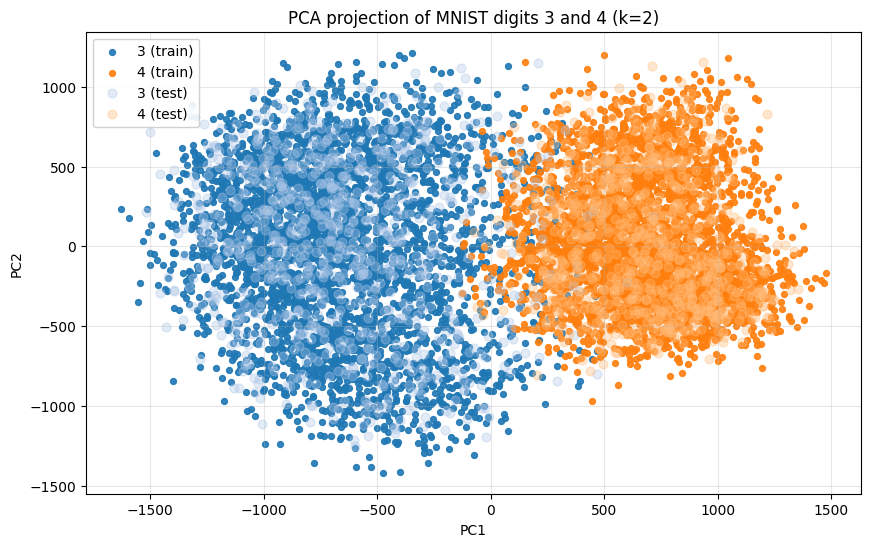

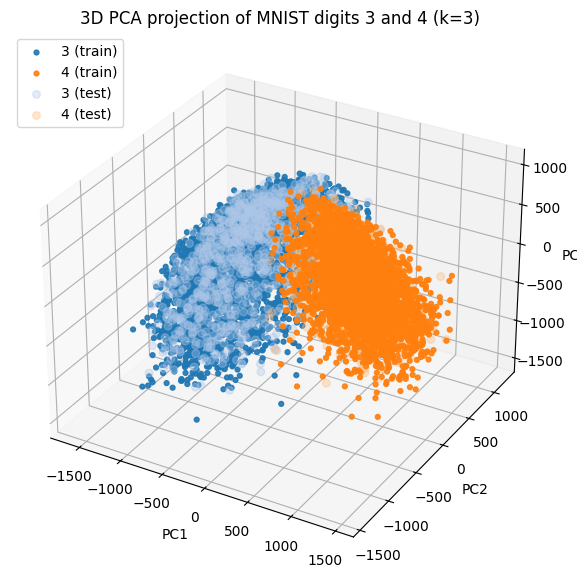

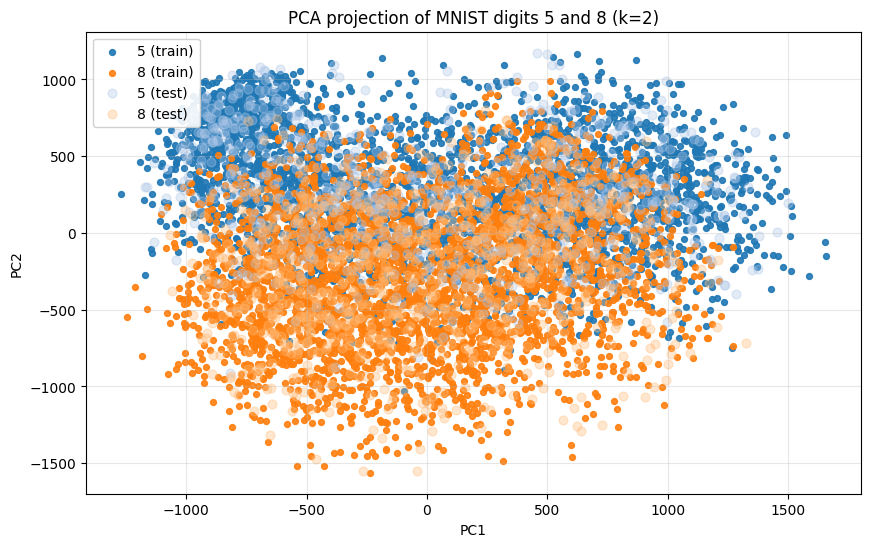

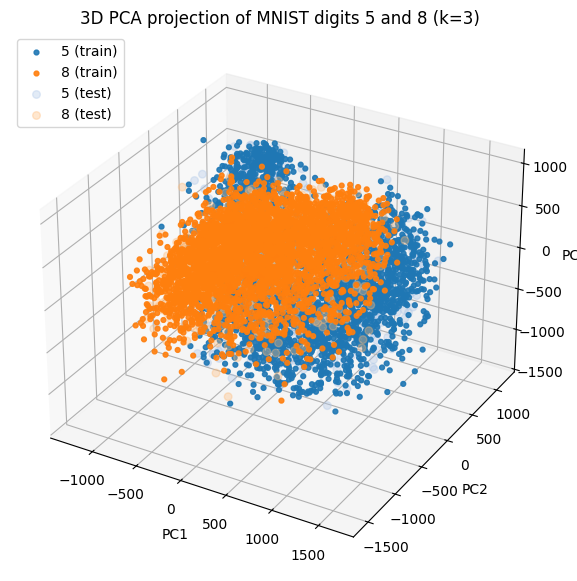

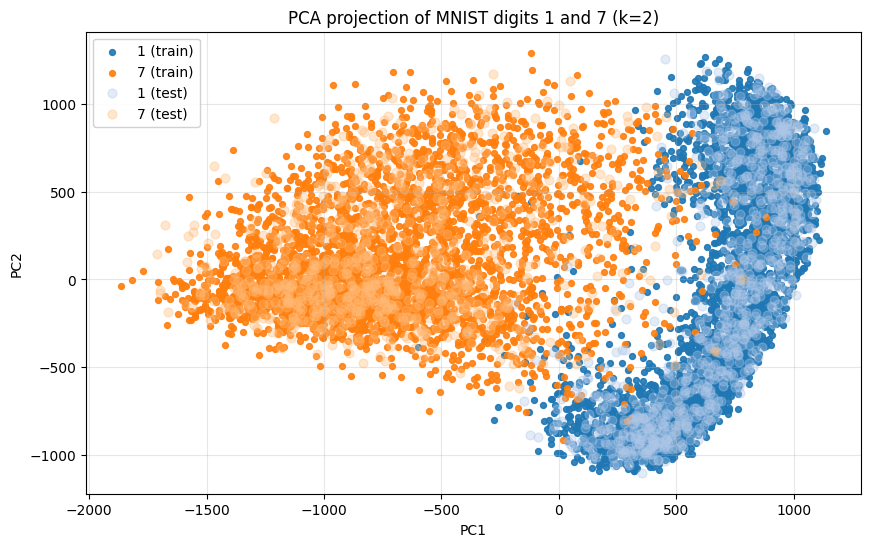

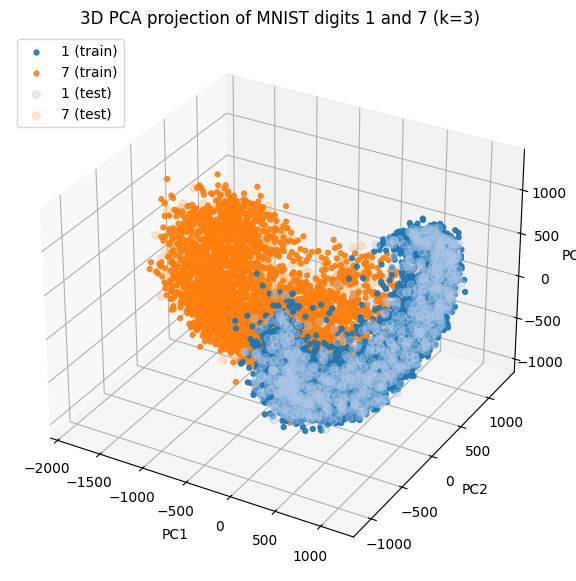

In [73]:
draw_plots(
        mnist_csv_path=csv_file_path,
        pairs=((3, 4), (5, 8), (1, 7)),
        test_ratio=0.2,
        seed=0
    )